In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import (
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)
from sklearn.neighbors import NearestNeighbors

from scipy.cluster.hierarchy import dendrogram, linkage

In [ ]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


In [ ]:
df.describe()

,CustomerID,Age,Annual Income (k$),Spending Score (1-100)
count,200.000000,200.000000,200.000000,200.000000
mean,100.500000,38.850000,60.560000,50.200000
std,57.879185,13.969007,26.264721,25.823522
min,1.000000,18.000000,15.000000,1.000000
25%,50.750000,28.750000,41.500000,34.750000
50%,100.500000,36.000000,61.500000,50.000000
75%,150.250000,49.000000,78.000000,73.000000
max,200.000000,70.000000,137.000000,99.000000


In [ ]:
df = df.rename(columns={
    "Annual Income (k$)": "Annual_Income",
    "Spending Score (1-100)": "Spending_Score"
})

df = df.drop(columns=["CustomerID"])

print("Columns after preprocessing:")
print(df.columns.tolist())

display(df.head())

Columns after preprocessing:
['Gender', 'Age', 'Annual_Income', 'Spending_Score']


,Gender,Age,Annual_Income,Spending_Score
0,Male,19,15,39
1,Male,21,15,81
2,Female,20,16,6
3,Female,23,16,77
4,Female,31,17,40


In [ ]:
label_encoder = LabelEncoder()

df["Gender"] = label_encoder.fit_transform(df["Gender"])

print("Gender Encoding:")
print(dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_))))

display(df.head())

Gender Encoding:
{'Female': np.int64(0), 'Male': np.int64(1)}


,Gender,Age,Annual_Income,Spending_Score
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


In [ ]:
numeric_columns = [
    "Age",
    "Annual_Income",
    "Spending_Score"
]

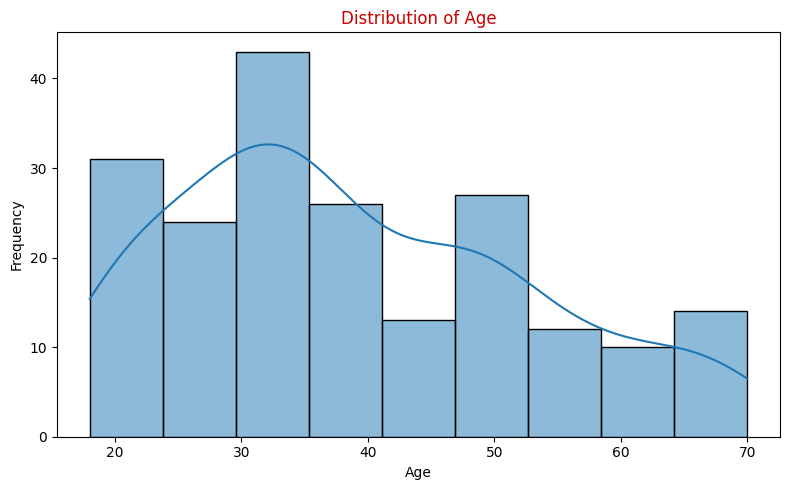

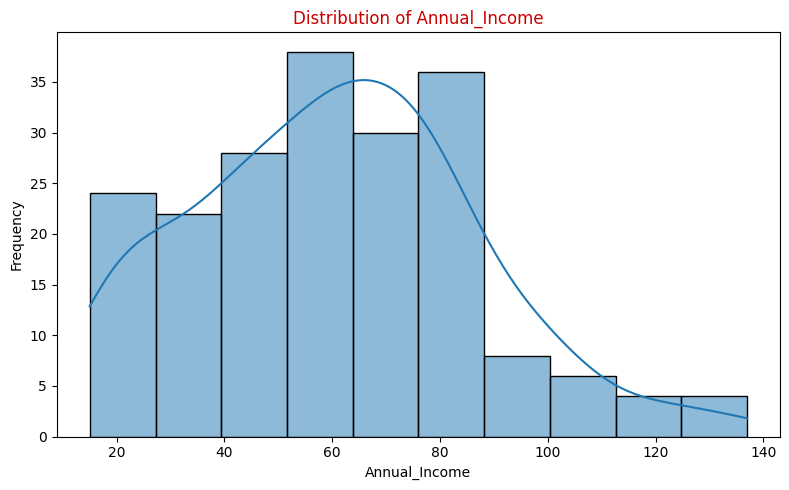

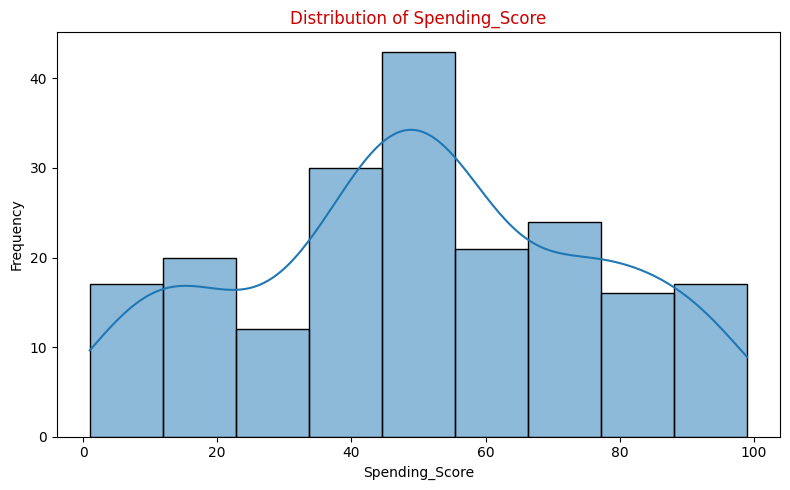

In [ ]:
for column in numeric_columns:
    plt.figure(figsize=(8, 5))

    sns.histplot(
        data=df,
        x=column,
        kde=True
    )

    plt.title(f"Distribution of {column}", color="#CC0000")
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.tight_layout()
    plt.show()

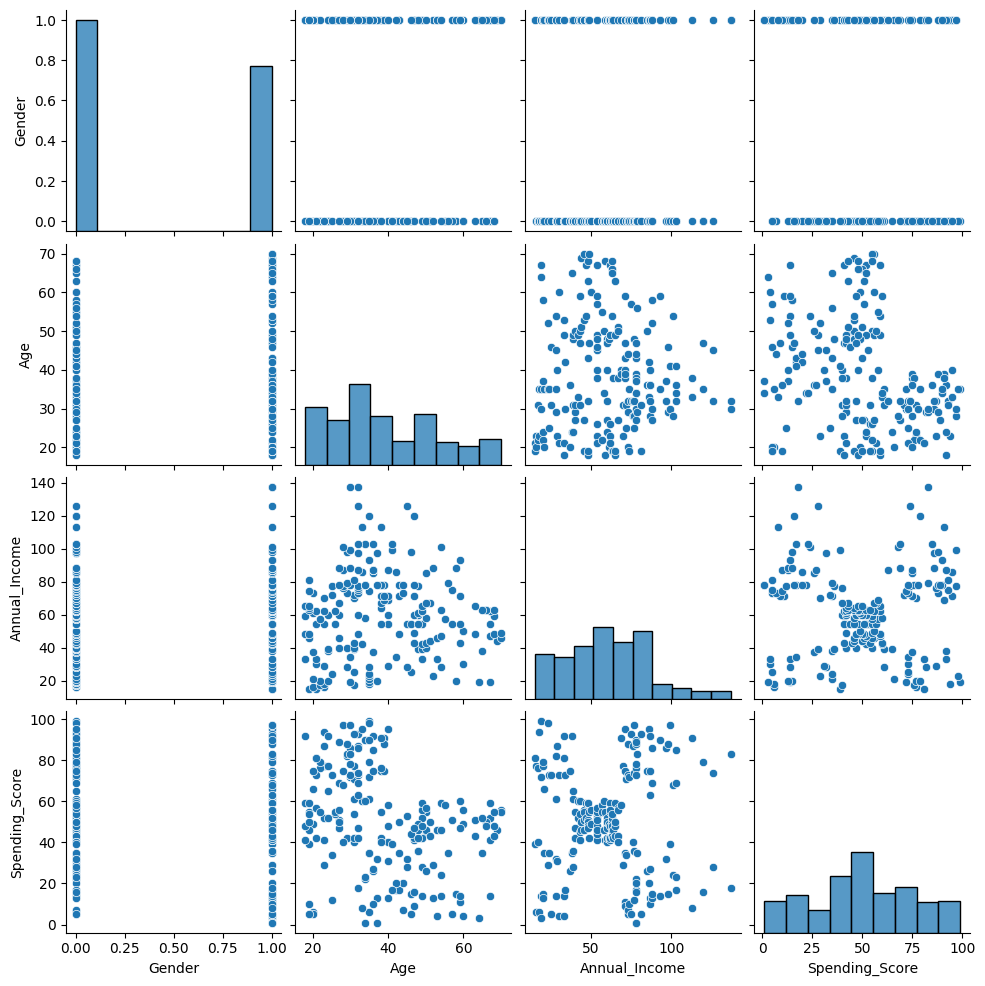

In [ ]:
sns.pairplot(df)

plt.show()

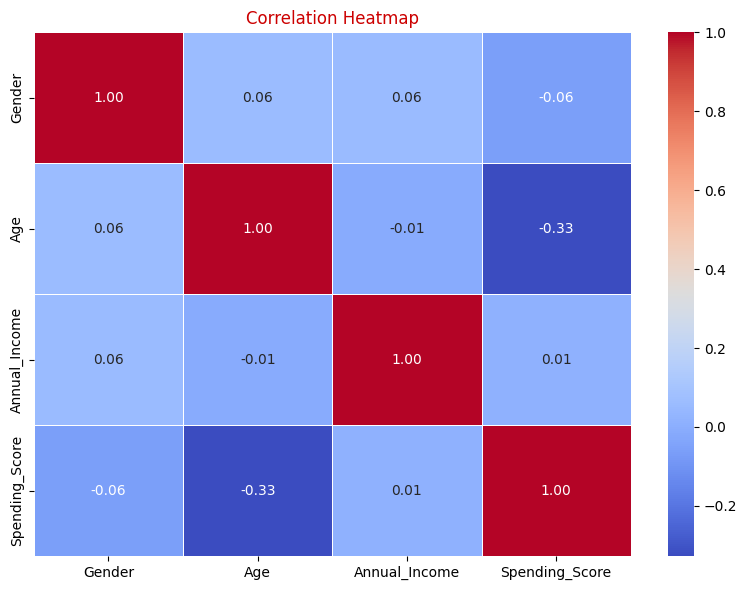

In [ ]:
plt.figure(figsize=(8, 6))

correlation_matrix = df.corr()

sns.heatmap(
    correlation_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Heatmap", color="#CC0000")
plt.tight_layout()
plt.show()

## EDA Summary

- The dataset contains 200 customers with no missing values and no duplicate records.
- Age and Spending Score show a moderate negative relationship, with a correlation of approximately -0.33.
- Annual Income and Spending Score have almost no linear correlation, with a correlation close to 0.01.
- The pairplot shows visible customer groupings when Annual Income and Spending Score are considered together.
- Annual Income and Spending Score are the most useful two features for visual customer segmentation because they represent two different dimensions of customer behaviour: purchasing capacity and spending behaviour.

In [ ]:
features_to_scale = [
    "Age",
    "Annual_Income",
    "Spending_Score"
]

scaler = StandardScaler()

df_scaled = df.copy()

df_scaled[features_to_scale] = scaler.fit_transform(
    df[features_to_scale]
)

display(df_scaled.head())

,Gender,Age,Annual_Income,Spending_Score
0,1,-1.424569,-1.738999,-0.434801
1,1,-1.281035,-1.738999,1.195704
2,0,-1.352802,-1.700830,-1.715913
3,0,-1.137502,-1.700830,1.040418
4,0,-0.563369,-1.662660,-0.395980


In [ ]:
print("Means after scaling:")
display(df_scaled[features_to_scale].mean().round(4))

print("\nStandard deviations after scaling:")
display(df_scaled[features_to_scale].std().round(4))

Means after scaling:


,0
Age,-0.0
Annual_Income,-0.0
Spending_Score,-0.0



Standard deviations after scaling:


,0
Age,1.0025
Annual_Income,1.0025
Spending_Score,1.0025


In [ ]:
df_2f = df_scaled[
    ["Annual_Income", "Spending_Score"]
].copy()

print("df_2f shape:", df_2f.shape)

display(df_2f.head())

df_2f shape: (200, 2)


,Annual_Income,Spending_Score
0,-1.738999,-0.434801
1,-1.738999,1.195704
2,-1.700830,-1.715913
3,-1.700830,1.040418
4,-1.662660,-0.395980


## Why StandardScaler is Required

StandardScaler is applied before clustering because K-Means, Hierarchical Clustering, and DBSCAN rely on distances between observations.

Without scaling, a feature with a larger numerical range can have a greater influence on distance calculations.

StandardScaler transforms the numerical features so that they have approximately zero mean and unit variance.

Gender is not scaled because it is already represented as a binary 0/1 variable.

For the primary clustering tasks, Annual_Income and Spending_Score are selected because they provide clear two-dimensional customer segmentation and allow the clusters to be visualized directly without PCA.

# Task 3 — K-Means Clustering

Objective: Determine a suitable number of clusters using the Elbow Method and Silhouette Score, then build the final K-Means model.

Expected output:
- Elbow plot
- Silhouette plot
- Final K-Means model
- Cluster visualization
- Cluster profile table

In [ ]:
inertia_values = []

k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(df_2f)
    inertia_values.append(kmeans.inertia_)

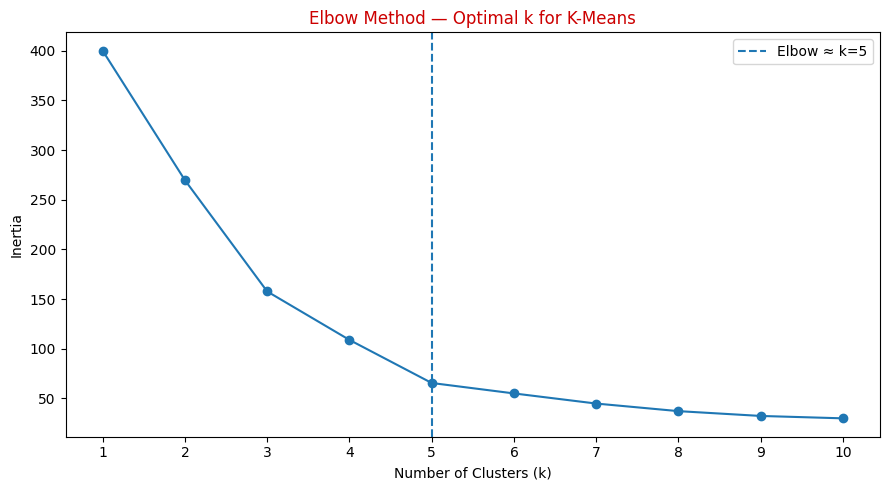

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    k_values,
    inertia_values,
    marker="o"
)

plt.axvline(
    x=5,
    linestyle="--",
    label="Elbow ≈ k=5"
)

plt.title(
    "Elbow Method — Optimal k for K-Means",
    color="#CC0000"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.xticks(k_values)
plt.legend()
plt.tight_layout()
plt.show()

## Elbow Method Interpretation

Inertia measures the total within-cluster squared distance between observations and their assigned cluster centroids.

As k increases, inertia decreases because more clusters allow observations to be represented by closer centroids.

The major reduction in inertia occurs up to approximately k = 5. After this point, the reduction becomes considerably smaller.

Therefore, k = 5 is selected as the elbow-based choice.

In [ ]:
silhouette_values = {}

for k in range(2, 11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    labels = kmeans.fit_predict(df_2f)

    silhouette_values[k] = silhouette_score(
        df_2f,
        labels
    )

silhouette_df = pd.DataFrame({
    "k": list(silhouette_values.keys()),
    "Silhouette_Score": list(silhouette_values.values())
})

display(silhouette_df)

,k,Silhouette_Score
0,2,0.321271
1,3,0.466585
2,4,0.493907
3,5,0.554657
4,6,0.539880
5,7,0.528149
6,8,0.455215
7,9,0.457085
8,10,0.443171


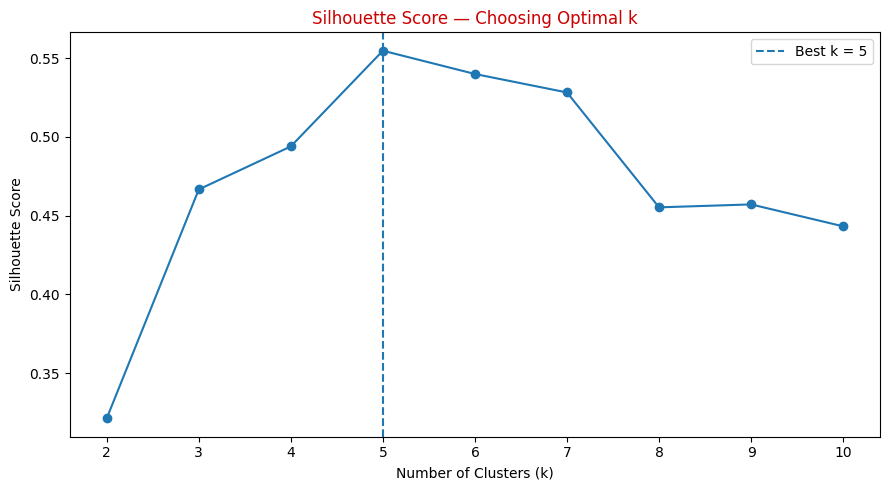

In [ ]:
plt.figure(figsize=(9, 5))

plt.plot(
    silhouette_df["k"],
    silhouette_df["Silhouette_Score"],
    marker="o"
)

best_k_silhouette = silhouette_df.loc[
    silhouette_df["Silhouette_Score"].idxmax(),
    "k"
]

plt.axvline(
    x=best_k_silhouette,
    linestyle="--",
    label=f"Best k = {best_k_silhouette}"
)

plt.title(
    "Silhouette Score — Choosing Optimal k",
    color="#CC0000"
)

plt.xlabel("Number of Clusters (k)")
plt.ylabel("Silhouette Score")
plt.legend()
plt.tight_layout()
plt.show()

## Silhouette Interpretation

The Silhouette Score measures how well observations fit within their assigned clusters compared with neighbouring clusters.

The highest Silhouette Score occurs at k = 5, with a score of approximately 0.555.

The Elbow Method and Silhouette Score therefore both support k = 5.

No meaningful discrepancy occurs between the two methods for this dataset.

In [ ]:
optimal_k = 5

kmeans = KMeans(
    n_clusters=optimal_k,
    random_state=42,
    n_init=10
)

kmeans_labels = kmeans.fit_predict(df_2f)

df["KMeans_Cluster"] = kmeans_labels

print("K-Means cluster counts:")
display(df["KMeans_Cluster"].value_counts().sort_index())

K-Means cluster counts:


,count
KMeans_Cluster,
0,81
1,39
2,22
3,35
4,23


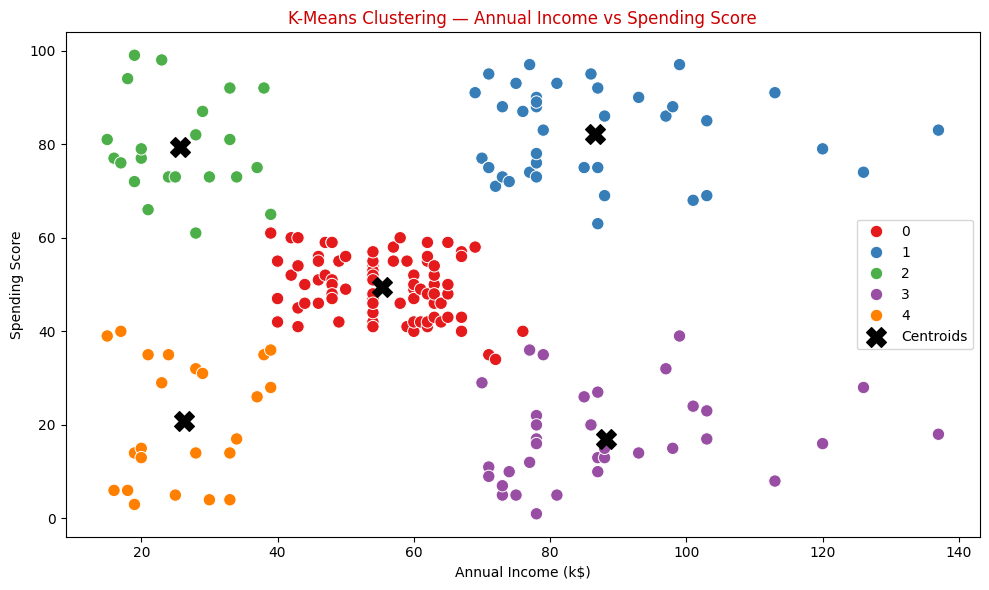

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    hue="KMeans_Cluster",
    data=df,
    palette="Set1",
    s=80
)

plt.scatter(
    kmeans.cluster_centers_[:, 0] * df["Annual_Income"].std() + df["Annual_Income"].mean(),
    kmeans.cluster_centers_[:, 1] * df["Spending_Score"].std() + df["Spending_Score"].mean(),
    c="black",
    marker="X",
    s=200,
    label="Centroids"
)

plt.title(
    "K-Means Clustering — Annual Income vs Spending Score",
    color="#CC0000"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
kmeans_profile = (
    df.groupby("KMeans_Cluster")
    [["Age", "Annual_Income", "Spending_Score"]]
    .mean()
    .round(2)
)

display(
    kmeans_profile.style
    .set_caption("K-Means Cluster Profile")
)

,Age,Annual_Income,Spending_Score
KMeans_Cluster,,,
0,42.720000,55.300000,49.520000
1,32.690000,86.540000,82.130000
2,25.270000,25.730000,79.360000
3,41.110000,88.200000,17.110000
4,45.220000,26.300000,20.910000


## K-Means Customer Segment Interpretation

### Cluster 0 — Moderate Income, Moderate Spenders
These customers have medium annual income and medium spending scores.

Business implication:
Use general promotions, membership benefits, and personalized offers to increase engagement and spending.

### Cluster 1 — High Income, High Spenders
These customers have high annual income and high spending scores.

Business implication:
Target them with premium products, loyalty rewards, VIP programs, and exclusive offers.

### Cluster 2 — Low Income, High Spenders
These customers have relatively low annual income but high spending scores.

Business implication:
Use affordable premium-looking products, discounts, bundles, and promotional campaigns.

### Cluster 3 — High Income, Low Spenders
These customers have high annual income but relatively low spending scores.

Business implication:
Use personalized recommendations, premium product demonstrations, and incentives designed to increase purchase frequency.

### Cluster 4 — Low Income, Low Spenders
These customers have relatively low income and low spending scores.

Business implication:
Use value-oriented products, budget promotions, discounts, and entry-level loyalty offers.

In [ ]:
hierarchical_linkage = linkage(
    df_2f,
    method="ward"
)

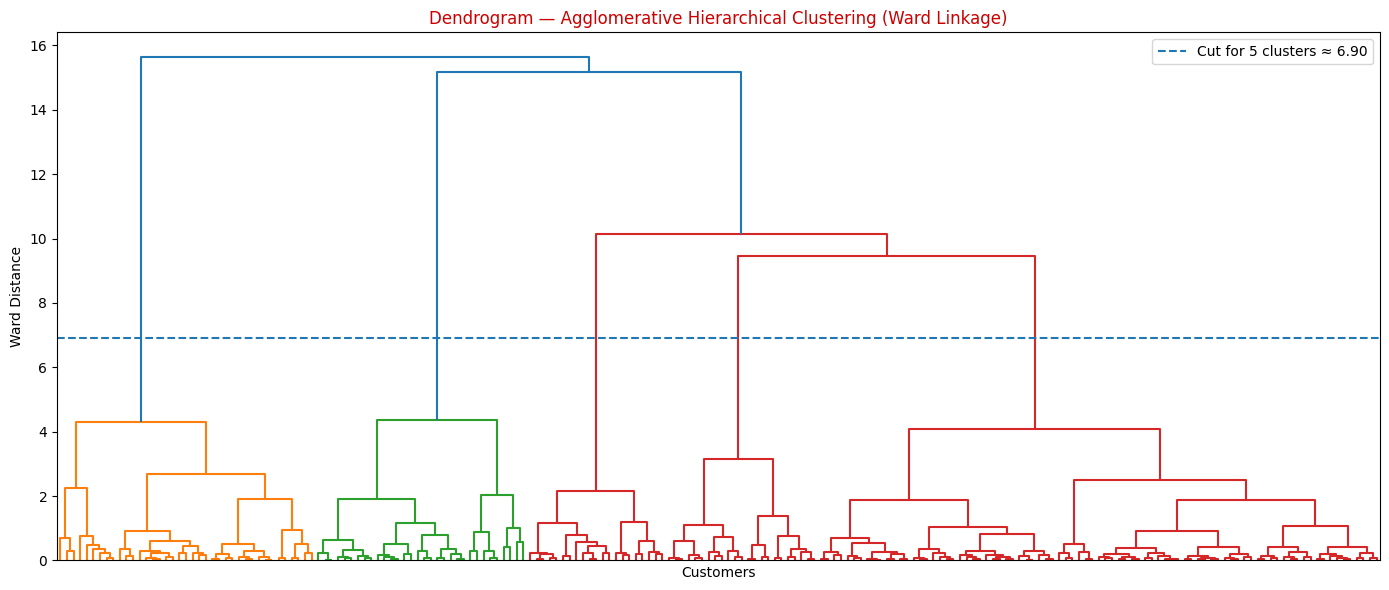

In [ ]:
plt.figure(figsize=(14, 6))

dendrogram(
    hierarchical_linkage,
    no_labels=True,
    color_threshold=None
)

cut_height = (
    hierarchical_linkage[-5, 2]
    + hierarchical_linkage[-4, 2]
) / 2

plt.axhline(
    y=cut_height,
    linestyle="--",
    label=f"Cut for 5 clusters ≈ {cut_height:.2f}"
)

plt.title(
    "Dendrogram — Agglomerative Hierarchical Clustering (Ward Linkage)",
    color="#CC0000"
)

plt.xlabel("Customers")
plt.ylabel("Ward Distance")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
hierarchical_model = AgglomerativeClustering(
    n_clusters=5,
    linkage="ward"
)

hier_labels = hierarchical_model.fit_predict(df_2f)

df["Hier_Cluster"] = hier_labels

print("Hierarchical cluster counts:")
display(df["Hier_Cluster"].value_counts().sort_index())

Hierarchical cluster counts:


,count
Hier_Cluster,
0,32
1,39
2,85
3,21
4,23


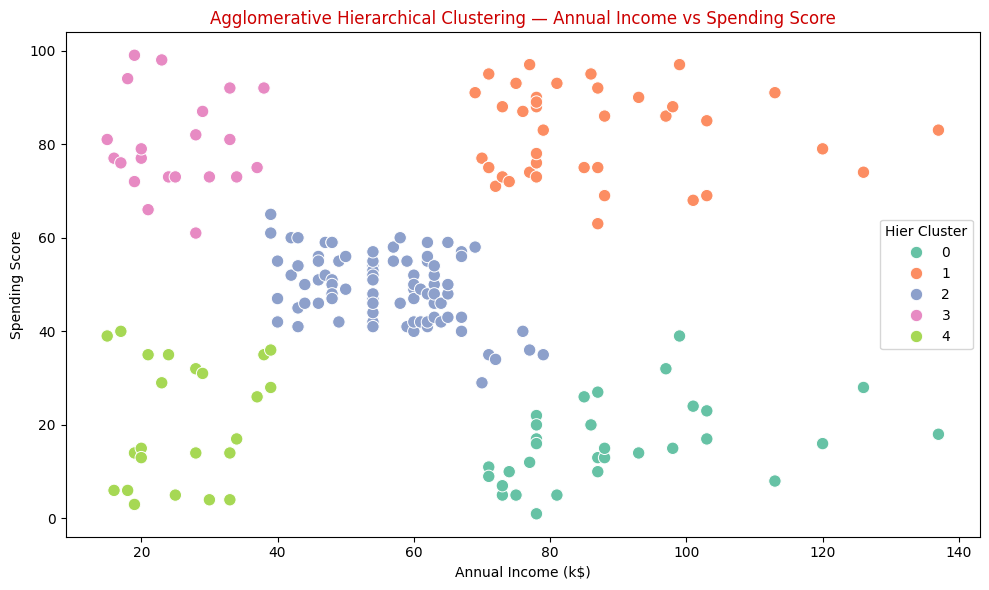

In [ ]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    hue="Hier_Cluster",
    data=df,
    palette="Set2",
    s=80
)

plt.title(
    "Agglomerative Hierarchical Clustering — Annual Income vs Spending Score",
    color="#CC0000"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend(title="Hier Cluster")
plt.tight_layout()
plt.show()

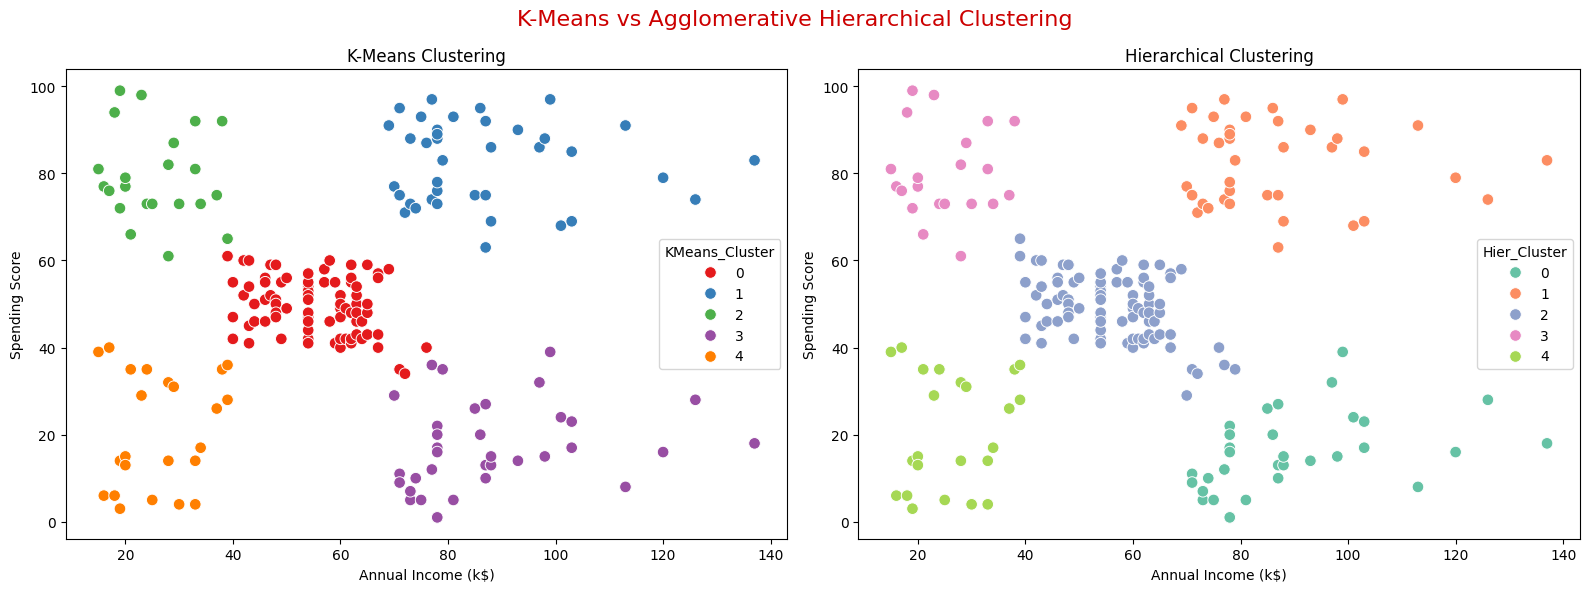

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    hue="KMeans_Cluster",
    data=df,
    palette="Set1",
    s=70,
    ax=axes[0]
)

axes[0].set_title("K-Means Clustering")
axes[0].set_xlabel("Annual Income (k$)")
axes[0].set_ylabel("Spending Score")

sns.scatterplot(
    x="Annual_Income",
    y="Spending_Score",
    hue="Hier_Cluster",
    data=df,
    palette="Set2",
    s=70,
    ax=axes[1]
)

axes[1].set_title("Hierarchical Clustering")
axes[1].set_xlabel("Annual Income (k$)")
axes[1].set_ylabel("Spending Score")

plt.suptitle(
    "K-Means vs Agglomerative Hierarchical Clustering",
    color="#CC0000",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
hierarchical_profile = (
    df.groupby("Hier_Cluster")
    [["Age", "Annual_Income", "Spending_Score"]]
    .mean()
    .round(2)
)

display(
    hierarchical_profile.style
    .set_caption("Hierarchical Cluster Profile")
)

,Age,Annual_Income,Spending_Score
Hier_Cluster,,,
0,41.000000,89.410000,15.590000
1,32.690000,86.540000,82.130000
2,42.480000,55.810000,49.130000
3,25.330000,25.100000,80.050000
4,45.220000,26.300000,20.910000


In [ ]:
neighbors = NearestNeighbors(n_neighbors=4)

neighbors.fit(df_2f)

distances, indices = neighbors.kneighbors(df_2f)

fourth_neighbor_distances = np.sort(
    distances[:, -1]
)

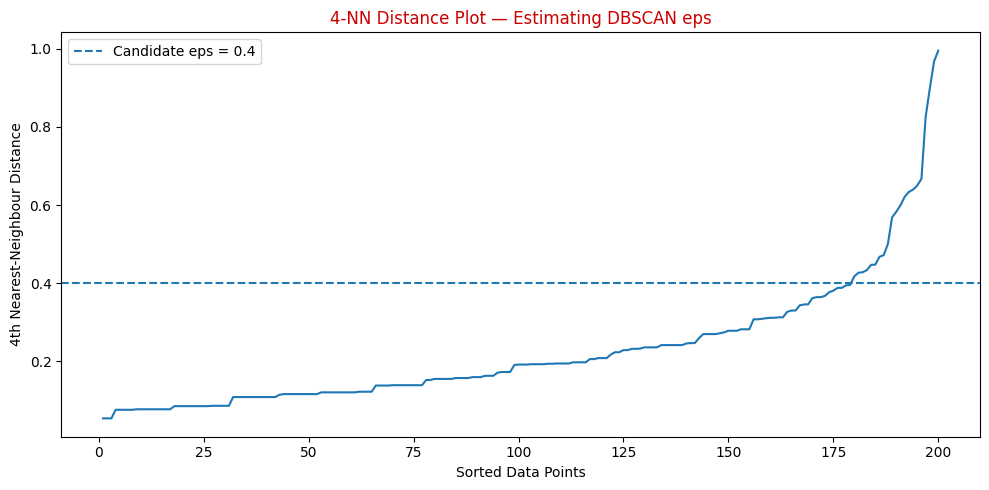

In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(
    range(1, len(fourth_neighbor_distances) + 1),
    fourth_neighbor_distances
)

plt.axhline(
    y=0.4,
    linestyle="--",
    label="Candidate eps = 0.4"
)

plt.title(
    "4-NN Distance Plot — Estimating DBSCAN eps",
    color="#CC0000"
)

plt.xlabel("Sorted Data Points")
plt.ylabel("4th Nearest-Neighbour Distance")
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
eps_values = [0.2, 0.3, 0.4, 0.5, 0.6]
min_samples_values = [3, 4, 5, 6]

dbscan_results = []

for eps in eps_values:
    for min_samples in min_samples_values:

        dbscan = DBSCAN(
            eps=eps,
            min_samples=min_samples
        )

        labels = dbscan.fit_predict(df_2f)

        n_clusters = len(
            set(labels)
            - {-1}
        )

        n_noise = np.sum(labels == -1)

        non_noise_mask = labels != -1

        if (
            n_clusters >= 2
            and non_noise_mask.sum() > n_clusters
        ):
            score = silhouette_score(
                df_2f[non_noise_mask],
                labels[non_noise_mask]
            )
        else:
            score = np.nan

        dbscan_results.append({
            "eps": eps,
            "min_samples": min_samples,
            "n_clusters": n_clusters,
            "noise_points": n_noise,
            "silhouette_score": score
        })

dbscan_grid = pd.DataFrame(dbscan_results)

display(dbscan_grid)

,eps,min_samples,n_clusters,noise_points,silhouette_score
0,0.2,3,13,44,0.469713
1,0.2,4,5,73,0.617282
2,0.2,5,7,77,0.585613
3,0.2,6,4,95,0.613836
4,0.3,3,9,14,0.472040
5,0.3,4,8,23,0.519746
6,0.3,5,7,35,0.524328
7,0.3,6,6,48,0.530244
8,0.4,3,4,10,0.395381
9,0.4,4,3,14,0.457570


In [ ]:
final_eps = 0.4
final_min_samples = 3

dbscan_model = DBSCAN(
    eps=final_eps,
    min_samples=final_min_samples
)

dbscan_labels = dbscan_model.fit_predict(df_2f)

df["DBSCAN_Cluster"] = dbscan_labels

print("DBSCAN cluster counts:")
display(
    df["DBSCAN_Cluster"]
    .value_counts()
    .sort_index()
)

DBSCAN cluster counts:


,count
DBSCAN_Cluster,
-1,10
0,126
1,3
2,33
3,28


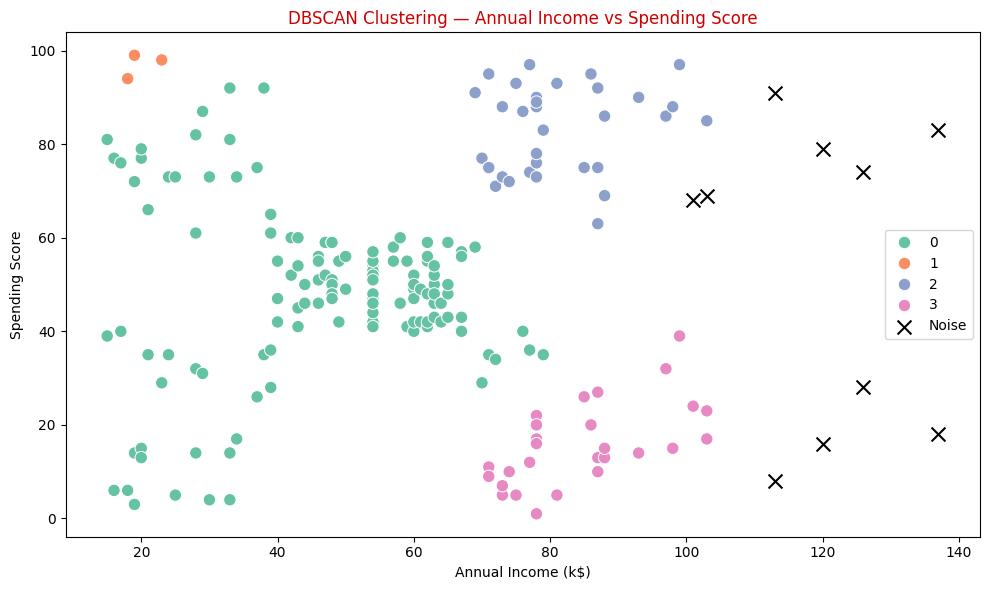

In [ ]:
plt.figure(figsize=(10, 6))

normal_points = df[
    df["DBSCAN_Cluster"] != -1
]

noise_points = df[
    df["DBSCAN_Cluster"] == -1
]

sns.scatterplot(
    data=normal_points,
    x="Annual_Income",
    y="Spending_Score",
    hue="DBSCAN_Cluster",
    palette="Set2",
    s=80
)

plt.scatter(
    noise_points["Annual_Income"],
    noise_points["Spending_Score"],
    c="black",
    marker="x",
    s=100,
    label="Noise"
)

plt.title(
    "DBSCAN Clustering — Annual Income vs Spending Score",
    color="#CC0000"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score")
plt.legend()
plt.tight_layout()
plt.show()

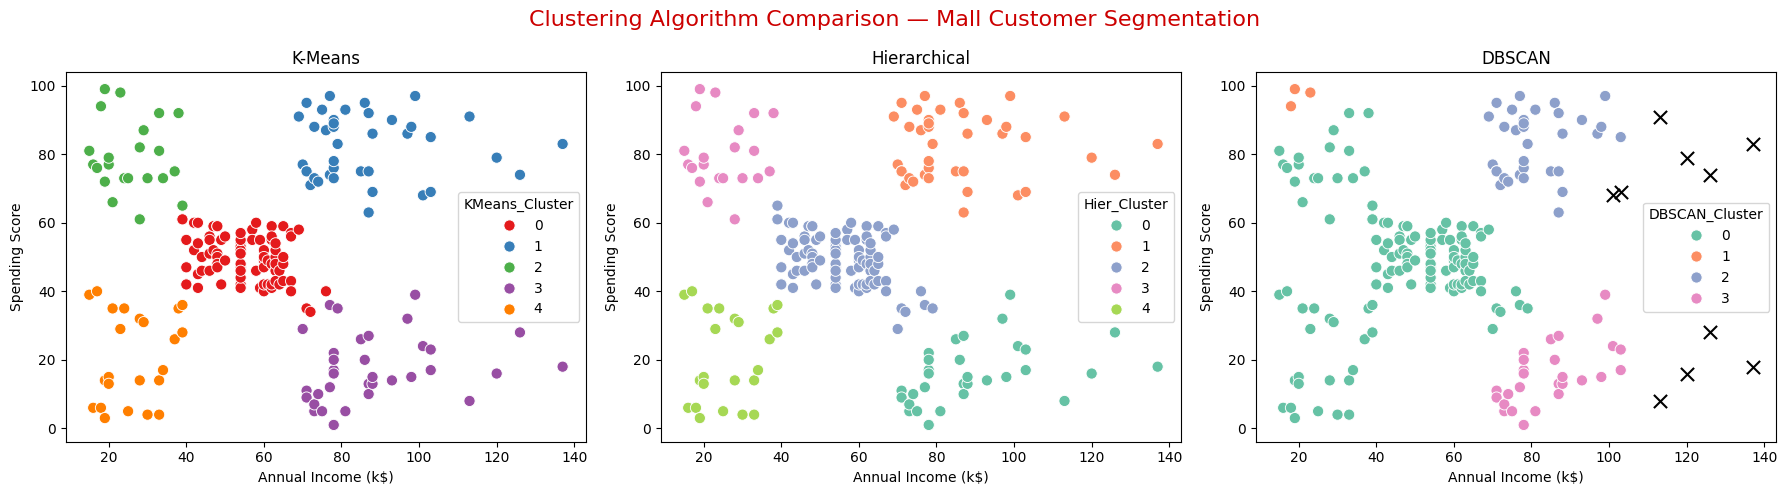

In [ ]:
fig, axes = plt.subplots(
    1,
    3,
    figsize=(18, 5)
)

sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Spending_Score",
    hue="KMeans_Cluster",
    palette="Set1",
    s=65,
    ax=axes[0]
)

axes[0].set_title("K-Means")
axes[0].set_xlabel("Annual Income (k$)")
axes[0].set_ylabel("Spending Score")

sns.scatterplot(
    data=df,
    x="Annual_Income",
    y="Spending_Score",
    hue="Hier_Cluster",
    palette="Set2",
    s=65,
    ax=axes[1]
)

axes[1].set_title("Hierarchical")
axes[1].set_xlabel("Annual Income (k$)")
axes[1].set_ylabel("Spending Score")

normal_points = df[df["DBSCAN_Cluster"] != -1]
noise_points = df[df["DBSCAN_Cluster"] == -1]

sns.scatterplot(
    data=normal_points,
    x="Annual_Income",
    y="Spending_Score",
    hue="DBSCAN_Cluster",
    palette="Set2",
    s=65,
    ax=axes[2]
)

axes[2].scatter(
    noise_points["Annual_Income"],
    noise_points["Spending_Score"],
    c="black",
    marker="x",
    s=90,
    label="Noise"
)

axes[2].set_title("DBSCAN")
axes[2].set_xlabel("Annual Income (k$)")
axes[2].set_ylabel("Spending Score")

plt.suptitle(
    "Clustering Algorithm Comparison — Mall Customer Segmentation",
    color="#CC0000",
    fontsize=16
)

plt.tight_layout()
plt.show()

In [ ]:
def calculate_clustering_metrics(
    algorithm_name,
    labels,
    data,
    exclude_noise=False
):

    labels = np.asarray(labels)

    if exclude_noise:
        mask = labels != -1
        evaluation_data = data.loc[mask]
        evaluation_labels = labels[mask]
    else:
        evaluation_data = data
        evaluation_labels = labels

    n_clusters = len(
        np.unique(evaluation_labels)
    )

    if n_clusters < 2:
        return {
            "Algorithm": algorithm_name,
            "n_clusters": n_clusters,
            "Silhouette Score": np.nan,
            "Davies-Bouldin Index": np.nan,
            "Calinski-Harabasz Index": np.nan
        }

    return {
        "Algorithm": algorithm_name,
        "n_clusters": n_clusters,
        "Silhouette Score": silhouette_score(
            evaluation_data,
            evaluation_labels
        ),
        "Davies-Bouldin Index": davies_bouldin_score(
            evaluation_data,
            evaluation_labels
        ),
        "Calinski-Harabasz Index": calinski_harabasz_score(
            evaluation_data,
            evaluation_labels
        )
    }

In [ ]:
metrics_summary = pd.DataFrame([
    calculate_clustering_metrics(
        "K-Means",
        kmeans_labels,
        df_2f
    ),

    calculate_clustering_metrics(
        "Hierarchical",
        hier_labels,
        df_2f
    ),

    calculate_clustering_metrics(
        "DBSCAN",
        dbscan_labels,
        df_2f,
        exclude_noise=True
    )
])

metrics_summary = metrics_summary.round(4)

display(metrics_summary)

,Algorithm,n_clusters,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,5,0.5547,0.5722,248.6493
1,Hierarchical,5,0.5538,0.5779,244.4103
2,DBSCAN,4,0.3954,0.6012,97.1723


## Metrics Interpretation

K-Means and Hierarchical Clustering produce very similar results because both identify the same broad customer structure.

K-Means has a slightly higher Silhouette Score and Calinski-Harabasz Index and a slightly lower Davies-Bouldin Index than Hierarchical Clustering for this selected five-cluster solution.

DBSCAN provides a density-based alternative and identifies noise observations, but its selected configuration produces lower overall clustering metrics on this dataset.

The metrics should be interpreted together with the business meaning and visual structure rather than using a single metric in isolation.

In [ ]:
final_cluster_profile = (
    df.groupby("KMeans_Cluster")
    [["Age", "Annual_Income", "Spending_Score"]]
    .mean()
    .round(2)
)

final_cluster_profile

,Age,Annual_Income,Spending_Score
KMeans_Cluster,,,
0,42.72,55.30,49.52
1,32.69,86.54,82.13
2,25.27,25.73,79.36
3,41.11,88.20,17.11
4,45.22,26.30,20.91


In [ ]:
final_comparison = metrics_summary.copy()

display(
    final_comparison.style
    .set_caption("Final Clustering Algorithm Comparison")
)

,Algorithm,n_clusters,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index
0,K-Means,5,0.554700,0.572200,248.649300
1,Hierarchical,5,0.553800,0.577900,244.410300
2,DBSCAN,4,0.395400,0.601200,97.172300
